In [1]:
import sys
import os

# Pega o caminho absoluto da pasta atual do notebook
current_dir = os.path.dirname(os.path.abspath('__file__'))

# Aponta para a pasta raiz (um nível acima, assumindo que o ipynb está em /notebooks)
root_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Adiciona a raiz ao caminho do sistema
if root_dir not in sys.path:
    sys.path.append(root_dir)

In [2]:
import pandas as pd
from src.utils.data_loader import load_preprocessed_data,load_raw_data
import unicodedata

In [3]:
df_raw = load_raw_data()
display(df_raw)

Posts carregados: 1736102


,id,title,selftext,author,subreddit,score,timestamp,num_comments,url,is_self,over_18,removed_by_category,lang,text,depth
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,NaN,RoyalChris,popculture,107449,2025-03-04T17:20:21+00:00,3736,https://reddit.com/r/popculture/comments/1j3g0...,False,False,NaN,en,Trudeau - ''I want to speak first directly to ...,0
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,S,wyokiddo,popculture,57062,2025-03-17T15:26:59+00:00,2743,https://reddit.com/r/popculture/comments/1jdfb...,False,False,NaN,en,Kim Kardashian endorses Nazi Elon Musk’s cyber...,0
2,1k7jcux,Candace Owens saying she no longer supports Do...,NaN,skyisscary,popculture,27509,2025-04-25T12:10:47+00:00,5419,https://reddit.com/r/popculture/comments/1k7jc...,False,False,NaN,en,Candace Owens saying she no longer supports Do...,0
3,1ilwij6,Kendrick Lamar called out for no white perform...,NaN,IrishStarUS,popculture,23908,2025-02-10T03:13:42+00:00,2525,https://reddit.com/r/popculture/comments/1ilwi...,False,False,NaN,en,Kendrick Lamar called out for no white perform...,0
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",NaN,RoyalChris,popculture,23502,2025-03-20T21:17:23+00:00,1152,https://reddit.com/r/popculture/comments/1jfzx...,False,False,NaN,en,"Elon Musk's daughter, Vivian Wilson, stars in ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227108,14ifnii,iVentoy is out now! Ease of Ventoy with just o...,iVentoy just got released some days ago.\n\nEx...,Floroform,selfhosted,537,2023-06-25T07:13:52+00:00,79,https://reddit.com/r/selfhosted/comments/14ifn...,False,False,NaN,en,iVentoy is out now! Ease of Ventoy with just o...,1
2227109,zqyg79,I created a library of full-color SVG icons of...,TL;DR:\n\n300+ full-color SVG icons of homelab...,lmm7425,selfhosted,536,2022-12-20T20:16:54+00:00,18,https://reddit.com/r/selfhosted/comments/zqyg7...,True,False,NaN,en,I created a library of full-color SVG icons of...,1
2227110,c6e90e,When your friend texts you that Micro Center j...,NaN,plazman30,selfhosted,536,2019-06-28T02:02:47+00:00,119,https://reddit.com/r/selfhosted/comments/c6e90...,False,False,NaN,en,When your friend texts you that Micro Center j...,1
2227111,r8kbmz,Not A typical Post but I hope it made you laugh,While I Was Browsing Github I Stumbled Upon Th...,DadOfLucifer,selfhosted,535,2021-12-04T07:25:47+00:00,68,https://reddit.com/r/selfhosted/comments/r8kbm...,True,False,NaN,en,Not A typical Post but I hope it made you laug...,1


In [4]:
df_0 = df_raw[df_raw['depth'] == 0]
subreddits_list = df_0['subreddit'].unique().tolist()
users_list = df_0['author'].unique().tolist()

print(f"Número de mensagens na primeira profundidade: {len(df_0)}")
print(f"Número de subreddits na primeira profundidade: {len(subreddits_list)}")
print(f"Número de autores na primeira profundidade: {len(users_list)}")

Número de mensagens na primeira profundidade: 238856
Número de subreddits na primeira profundidade: 998
Número de autores na primeira profundidade: 161740


In [5]:
df_teste = load_preprocessed_data()

In [6]:
len(df_teste)

1665371

In [8]:
diff = pd.concat([df_raw, df_teste]).drop_duplicates(keep=False)

display(diff)

,id,title,selftext,author,subreddit,score,timestamp,num_comments,url,is_self,over_18,removed_by_category,lang,text,depth,text_clean
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,NaN,RoyalChris,popculture,107449.0,2025-03-04T17:20:21+00:00,3736.0,https://reddit.com/r/popculture/comments/1j3g0...,False,False,NaN,en,Trudeau - ''I want to speak first directly to ...,0,NaN
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,S,wyokiddo,popculture,57062.0,2025-03-17T15:26:59+00:00,2743.0,https://reddit.com/r/popculture/comments/1jdfb...,False,False,NaN,en,Kim Kardashian endorses Nazi Elon Musk’s cyber...,0,NaN
2,1k7jcux,Candace Owens saying she no longer supports Do...,NaN,skyisscary,popculture,27509.0,2025-04-25T12:10:47+00:00,5419.0,https://reddit.com/r/popculture/comments/1k7jc...,False,False,NaN,en,Candace Owens saying she no longer supports Do...,0,NaN
3,1ilwij6,Kendrick Lamar called out for no white perform...,NaN,IrishStarUS,popculture,23908.0,2025-02-10T03:13:42+00:00,2525.0,https://reddit.com/r/popculture/comments/1ilwi...,False,False,NaN,en,Kendrick Lamar called out for no white perform...,0,NaN
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",NaN,RoyalChris,popculture,23502.0,2025-03-20T21:17:23+00:00,1152.0,https://reddit.com/r/popculture/comments/1jfzx...,False,False,NaN,en,"Elon Musk's daughter, Vivian Wilson, stars in ...",0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135752,14ifnii,NaN,NaN,NaN,selfhosted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,iVentoy is out now! Ease of Ventoy with just o...,1,iventoy ease ventoy iventoy release exactly se...
2135753,zqyg79,NaN,NaN,NaN,selfhosted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I created a library of full-color SVG icons of...,1,create library full color icon homelab relate ...
2135754,c6e90e,NaN,NaN,NaN,selfhosted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When your friend texts you that Micro Center j...,1,friend text micro center shipment damn enjoy m...
2135755,r8kbmz,NaN,NaN,NaN,selfhosted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not A typical Post but I hope it made you laug...,1,typical post hope make laugh browse github stu...


In [9]:
words = ["AWALT","AWFL","AWFUL","Alpha male","Beta male","Becky","Black pill","Blue pill","Blue pill rage","Body count","Bop","Brad","Briffault's Law","Chad","Cope","Copium","Corporate slave","Cracked","Cracking","Cuck","E-Girl",
    "False allegations myth","Femoid","FHO","Foid","Frame","Feminist agenda","Gymcel","Gynocentrism","Hamster","High-value male","High-value man","Hyperagency","Hypergamy","Hypergamous","Incel","Involuntary celibate","Looksmaxxing",
    "Male supremacism","Maintaining frame","Manosphere","The Matrix","Men going their own way","Men's rights activist","Men's rights movement","Mewing","MGTOW","Mogging","MRA","MRM","Normie","OnlyFans girl","Patriarchy denialism","Pick-up artist",
    "PUA","Rage bait","rationalization hamster","Red pill","Red pill rage","Reverse discrimination","SA","Sigma male","Simp","SMV","Sexual market value","Soy boy","Soya boy","Stacy","Statusmaxxing","Thot","thottie","Unalive","Wagecuck","White knighting",
]

In [10]:
words = set([w.lower() for w in words])
df_0["text_lower"] = df_0["text"].str.lower()

df_0["is_manosphere"] = df_0["text_lower"].apply(
    lambda x: any(w in x for w in words)
)

In [11]:
print(f"A porcentagem de posts considerados da manosfera: {len(df_0[df_0['is_manosphere'] == True])}/{len(df_0)}: {len(df_0[df_0['is_manosphere'] == True])/len(df_0)*100:.2f}%")

A porcentagem de posts considerados da manosfera: 62586/238856: 26.20%


In [12]:
result = df_0.groupby("subreddit").agg(
    total_posts=("is_manosphere", "count"),
    misogynistic_posts=("is_manosphere", "sum")
)

result["misogyny_ratio"] = (
    result["misogynistic_posts"] /
    result["total_posts"]
)

In [13]:
subreddits_manosphere = result[result['misogyny_ratio'] > 0.5]
display(subreddits_manosphere.head(50))


,total_posts,misogynistic_posts,misogyny_ratio
subreddit,,,
abortiondebate,295,233,0.789831
adhd,295,166,0.562712
adolescencenetflix,55,33,0.600000
advice,296,172,0.581081
aita_wibta_public,298,162,0.543624
aitah,299,197,0.658863
amitheasshole,299,267,0.892977
amiwrong,298,208,0.697987
arrangedmarriage,286,185,0.646853


In [22]:
import pandas as pd
import re

# 1. O .copy() evita o erro "SettingWithCopyWarning"
df_0 = df_raw[df_raw['depth'] == 0].copy()

subreddits_list = df_0['subreddit'].unique().tolist()
users_list = df_0['author'].unique().tolist()

print(f"Número de mensagens na primeira profundidade: {len(df_0)}")
print(f"Número de subreddits na primeira profundidade: {len(subreddits_list)}")
print(f"Número de autores na primeira profundidade: {len(users_list)}\n")

# Dicionário original (convertido para minúsculas por precaução na hora do regex)
words = [
    "awalt", "awfl", "awful", "alpha male", "beta male", "becky", "black pill", 
    "blue pill", "blue pill rage", "body count", "bop", "brad", "briffault's law", 
    "chad", "cope", "copium", "corporate slave", "cracked", "cracking", "cuck", 
    "e-girl", "false allegations myth", "femoid", "fho", "foid", "frame", 
    "feminist agenda", "gymcel", "gynocentrism", "hamster", "high-value male", 
    "high-value man", "hyperagency", "hypergamy", "hypergamous", "incel", 
    "involuntary celibate", "looksmaxxing", "male supremacism", "maintaining frame", 
    "manosphere", "the matrix", "men going their own way", "men's rights activist", 
    "men's rights movement", "mewing", "mgtow", "mogging", "mra", "mrm", "normie", 
    "onlyfans girl", "patriarchy denialism", "pick-up artist", "pua", "rage bait", 
    "rationalization hamster", "red pill", "red pill rage", "reverse discrimination", 
    "sa", "sigma male", "simp", "smv", "sexual market value", "soy boy", "soya boy", 
    "stacy", "statusmaxxing", "thot", "thottie", "unalive", "wagecuck", "white knighting"
]

# 2. O Pulo do Gato: Cria uma string de Regex com delimitadores de palavra (\b)
# Fica no formato: \b(?:awalt|awfl|awful|...)\b
pattern = r'\b(?:' + '|'.join(re.escape(w) for w in words) + r')\b'

# 3. Busca Vetorizada e Blindada
# na=False: impede que linhas vazias (NaN) quebrem o código
# case=False: ignora maiúsculas/minúsculas automaticamente (dispensa o text_lower)
df_0["is_manosphere"] = df_0["text"].str.contains(pattern, case=False, na=False, regex=True)

# Como o True vale 1 e o False vale 0, o .sum() já te dá o total de posts da manosfera
qtd_manosphere = df_0["is_manosphere"].sum()
total = len(df_0)

print(f"Posts considerados da manosfera: {qtd_manosphere}/{total} ({qtd_manosphere/total*100:.2f}%)\n")

# Agrupamento
result = df_0.groupby("subreddit").agg(
    total_posts=("is_manosphere", "count"),
    misogynistic_posts=("is_manosphere", "sum")
)

result["misogyny_ratio"] = result["misogynistic_posts"] / result["total_posts"]

# Dica: adicionei o sort_values para os piores subreddits aparecerem no topo!
subreddits_manosphere = result[result['misogyny_ratio'] > 0.5].sort_values(by="misogyny_ratio", ascending=False)
display(subreddits_manosphere.head(50))

Número de mensagens na primeira profundidade: 238856
Número de subreddits na primeira profundidade: 998
Número de autores na primeira profundidade: 161740

Posts considerados da manosfera: 5013/238856 (2.10%)



,total_posts,misogynistic_posts,misogyny_ratio
subreddit,,,
gigilako,40,37,0.925000
offmychestph,195,142,0.728205
marriedredpill,295,200,0.677966
exredpill,295,173,0.586441
mewing,240,136,0.566667
pinoybigbrother,134,75,0.559701
theredpill,297,150,0.505051


In [21]:
import pandas as pd
import torch
from transformers import pipeline

print("Carregando o modelo especialista em Misoginia (MilaNLP)...")
# Usando exatamente o modelo que você encontrou
detector_misoginia = pipeline(
    "text-classification", 
    model="MilaNLProc/bert-base-uncased-ear-misogyny", 
    device=-1  # Mantemos na CPU
)

df_teste = df_0[df_0['subreddit'].isin(subreddits_manosphere.index.tolist())]
# Pega uma amostra de 1000 posts para testar a qualidade
df_teste = df_teste.head(1000).copy()
textos = df_teste["text"].astype(str).tolist()

print(f"Lendo {len(textos)} posts...")

# Rodamos a predição (truncation=True continua obrigatório para textos longos do Reddit)
resultados = detector_misoginia(
    textos, 
    truncation=True, 
    max_length=512, 
    batch_size=16
)

# Extraímos os dados
df_teste["classificacao_label"] = [res["label"] for res in resultados]
df_teste["certeza_modelo"] = [res["score"] for res in resultados]

# Considerando que LABEL_1 seja o discurso misógino (padrão do HuggingFace)
df_teste["is_misogynistic"] = df_teste["classificacao_label"] == "LABEL_1"

# Resumo
print("\n=== RESULTADO DA AMOSTRA ===")
qtd_misoginia = df_teste['is_misogynistic'].sum()
print(f"Posts classificados como misóginos: {qtd_misoginia}/{len(df_teste)} ({qtd_misoginia/len(df_teste)*100:.2f}%)")

# Vamos olhar os piores para ver se o modelo é realmente bom!
display(df_teste[df_teste["is_misogynistic"] == True][["subreddit", "text", "certeza_modelo"]].sort_values(by="certeza_modelo", ascending=False).head(10))

Carregando o modelo especialista em Misoginia (MilaNLP)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28797.78it/s]


Lendo 1000 posts...

=== RESULTADO DA AMOSTRA ===
Posts classificados como misóginos: 0/1000 (0.00%)


,subreddit,text,certeza_modelo


In [23]:
# Isso vai listar exatamente quais foram os rótulos que o modelo devolveu
print(df_teste["classificacao_label"].value_counts())

classificacao_label
non-misogynist    962
misogynist         38
Name: count, dtype: int64


In [28]:
df_teste.to_csv("teste.csv")

In [44]:
print(f"Estudo sobre a quantidade de mensagens que um autor publicou em subreddits na profundidade 0")

author_posts = (
    df_0.groupby('author')
        .size()
        .sort_values(ascending=False)
)

print(author_posts.describe())

Estudo sobre a quantidade de mensagens que um autor publicou em subreddits na profundidade 0
count    161740.000000
mean          1.476790
std          62.261531
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max       25026.000000
dtype: float64


In [45]:
author_posts = author_posts[author_posts.index != '[deleted]']
author_posts = author_posts[author_posts > 1]
author_posts

author
psychologyofsex       273
mvea                  220
Beratungsmarketing    190
zadraaa               161
relevantlife          148
                     ... 
0sculum3stm0rtis        2
_worst_friend_ever      2
26852515                2
CastIronCarnivore       2
yeh1234gee              2
Length: 21119, dtype: int64

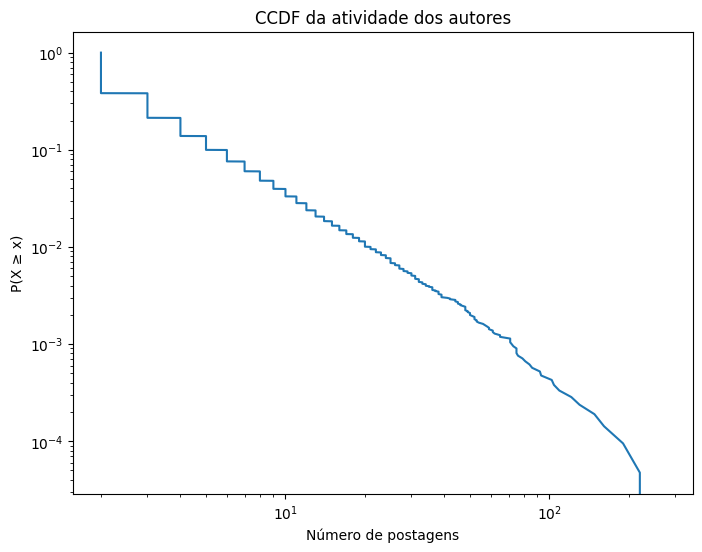

In [47]:
import numpy as np
import matplotlib.pyplot as plt

x = np.sort(author_posts.values)

ccdf = 1 - np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(8,6))
plt.plot(x, ccdf)

plt.xlabel("Número de postagens")
plt.ylabel("P(X ≥ x)")
plt.title("CCDF da atividade dos autores")

plt.xscale("log")
plt.yscale("log")

plt.show()

In [48]:
df_subreddits = pd.read_parquet("../data/processed/ranking_subreddits.parquet")
df_subreddits

,subreddit,n_keywords,keywords
0,r/TrueUnpopularOpinion,60,"[AWALT, AWFL, AWFUL, Alpha male, Beta male, Be..."
1,r/redscarepod,59,"[AWALT, AWFL, Alpha male, Beta male, Becky, Bl..."
2,r/AITAH,55,"[AWALT, AWFL, AWFUL, Alpha male, Beta male, Be..."
3,r/teenagers,54,"[Alpha male, Beta male, Black pill, Body count..."
4,r/AskReddit,53,"[AWALT, AWFL, Alpha male, Beta male, Becky, Bl..."
...,...,...,...
995,r/aviation,6,"[FHO, Manosphere, MRM, Blue pill, Sigma male, ..."
996,r/ItaliaPersonalFinance,6,"[Chad, E-Girl, High-value male, Normie, SA, Wa..."
997,r/JEEAdv25dailyupdates,6,"[Cope, Incel, Looksmaxxing, The Matrix, Moggin..."
998,r/MechanicalPandey,6,"[Briffault’s Law, Feminist agenda, Gynocentris..."


In [50]:
subreddit_sets = {
    row.subreddit: set(row.keywords)
    for _, row in df_subreddits.iterrows()
}

In [51]:
from itertools import combinations
import pandas as pd

rows = []

for s1, s2 in combinations(subreddit_sets.keys(), 2):
    inter = len(subreddit_sets[s1] & subreddit_sets[s2])
    union = len(subreddit_sets[s1] | subreddit_sets[s2])

    rows.append({
        "sub1": s1,
        "sub2": s2,
        "jaccard": inter / union
    })

similarities = pd.DataFrame(rows)
similarities.sort_values("jaccard", ascending=False).head(20)

,sub1,sub2,jaccard
3990,r/AskReddit,r/PurplePillDebate,0.872727
9947,r/NoStupidQuestions,r/AskMenAdvice,0.829787
4989,r/PurplePillDebate,r/NoStupidQuestions,0.788462
4992,r/PurplePillDebate,r/AskMenAdvice,0.788462
12917,r/AskMenAdvice,r/AmIOverreacting,0.765957
1001,r/redscarepod,r/AskReddit,0.750000
3995,r/AskReddit,r/NoStupidQuestions,0.745455
3998,r/AskReddit,r/AskMenAdvice,0.745455
5004,r/PurplePillDebate,r/GenZ,0.745098
9960,r/NoStupidQuestions,r/changemyview,0.744681


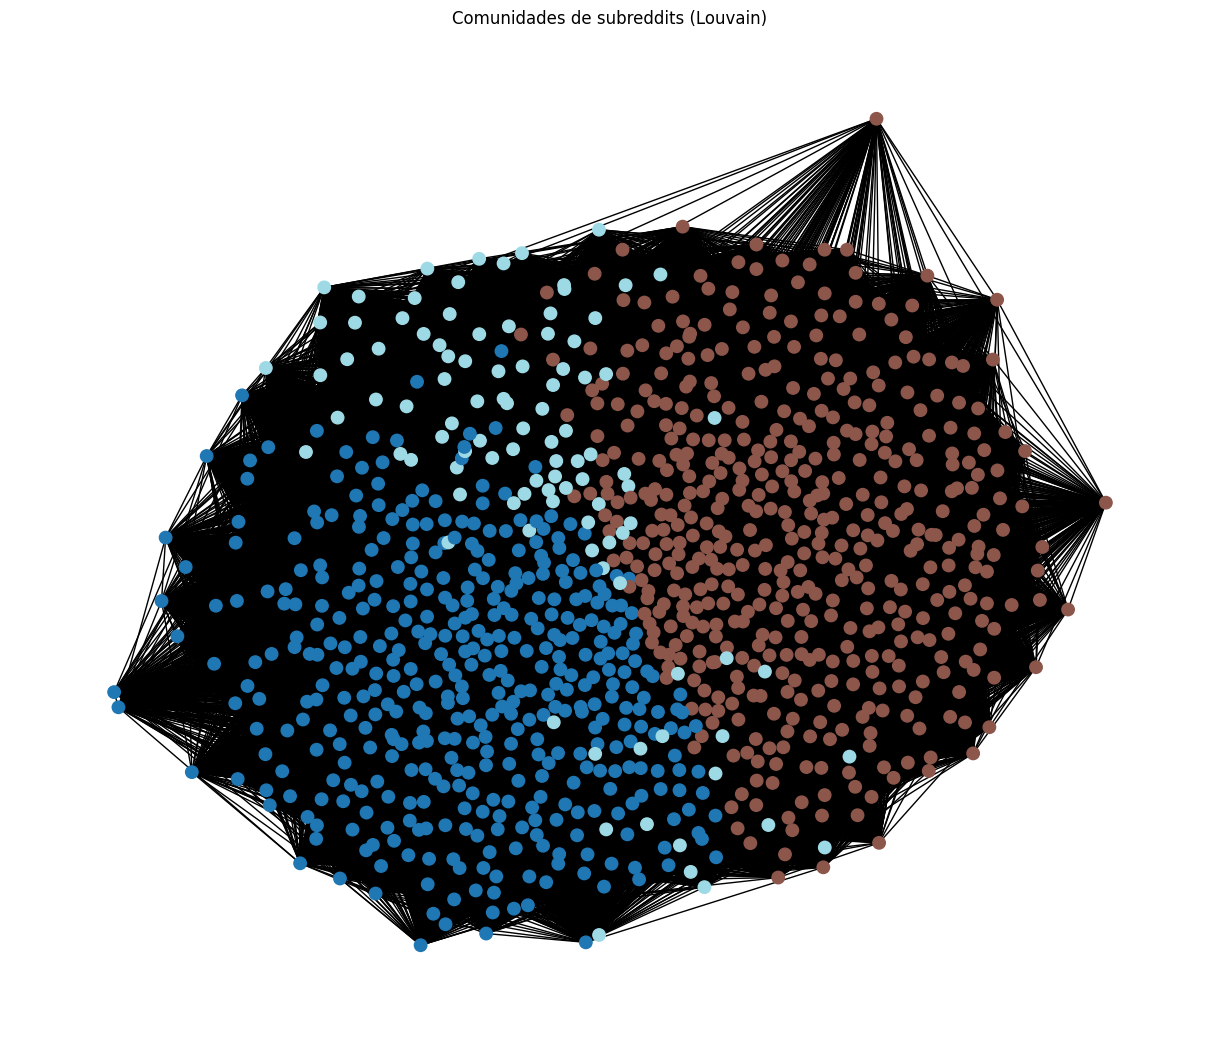

In [58]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

# adiciona nós
for s in subreddit_sets:
    G.add_node(s)

# arestas por similaridade
threshold = 0.10  # ajuste (0.05–0.2 costuma funcionar bem)

for s1, s2 in combinations(subreddit_sets.keys(), 2):

    inter = len(subreddit_sets[s1] & subreddit_sets[s2])
    union = len(subreddit_sets[s1] | subreddit_sets[s2])

    jaccard = inter / union

    if jaccard >= threshold:
        G.add_edge(s1, s2, weight=jaccard)

from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G, weight="weight")

# mapear comunidade
node_community = {}

for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

colors = [node_community[n] for n in G.nodes()]

nx.draw(
    G,
    pos,
    node_color=colors,
    with_labels=False,
    node_size=80,
    cmap=plt.cm.tab20
)

plt.title("Comunidades de subreddits (Louvain)")
plt.show()

In [59]:
communities

[{'r/10thDentist',
  'r/196',
  'r/4bmovement',
  'r/4tran4',
  'r/50501',
  'r/AITAH',
  'r/AITA_WIBTA_PUBLIC',
  'r/AMA',
  'r/Abortiondebate',
  'r/AdolescenceNetflix',
  'r/Adulting',
  'r/Advice',
  'r/Aging',
  'r/AllThatIsInteresting',
  'r/AmIOverreacting',
  'r/AmITheAngel',
  'r/AmITheDevil',
  'r/Anarcho_Capitalism',
  'r/AreTheStraightsOK',
  'r/Arrangedmarriage',
  'r/AsianMasculinity',
  'r/AskAChinese',
  'r/AskAChristian',
  'r/AskAGerman',
  'r/AskALiberal',
  'r/AskAnAustralian',
  'r/AskConservatives',
  'r/AskFeminists',
  'r/AskGaybrosOver30',
  'r/AskHistorians',
  'r/AskIndia',
  'r/AskIndianMen',
  'r/AskIndianWomen',
  'r/AskMen',
  'r/AskMenAdvice',
  'r/AskMenOver30',
  'r/AskPH',
  'r/AskReddit',
  'r/AskSerbia',
  'r/AskSocialScience',
  'r/AskTrumpSupporters',
  'r/AskUK',
  'r/AskUS',
  'r/AskWomenNoCensor',
  'r/AskWomenOver30',
  'r/Askpolitics',
  'r/Asmongold',
  'r/BPDlovedones',
  'r/BlackPeopleTwitter',
  'r/BlackPillScience',
  'r/BlatantMisogyny'

In [60]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

X = mlb.fit_transform(df_subreddits["keywords"])
labels = df_subreddits["subreddit"]

from umap import UMAP

umap = UMAP(
    n_neighbors=10,
    min_dist=0.3,
    metric="jaccard",
    random_state=42
)

embedding = umap.fit_transform(X)

/home/mateus/reddit/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mateus/reddit/venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/mateus/reddit/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


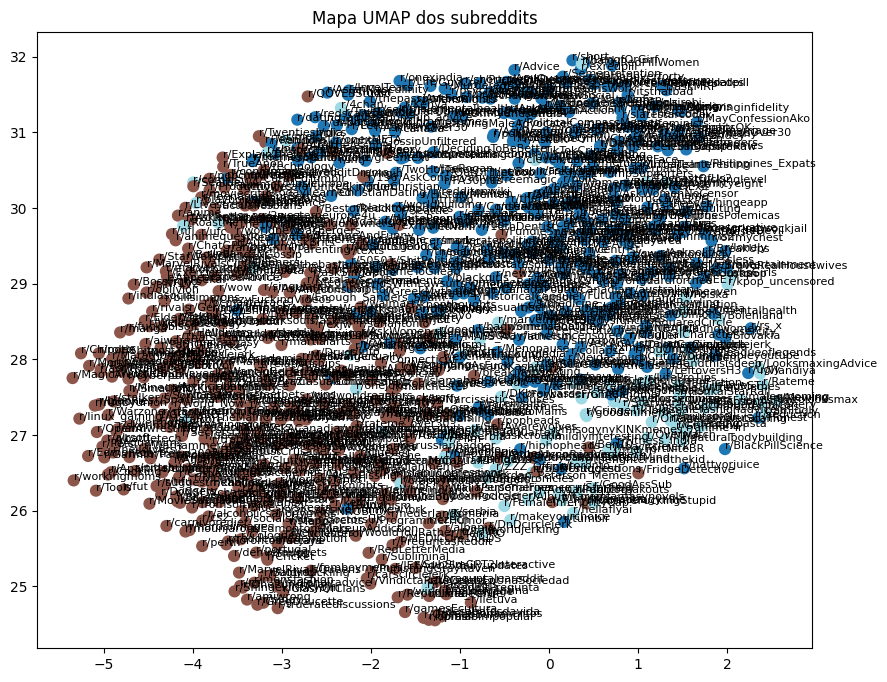

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[node_community[s] for s in labels],
    cmap="tab20",
    s=60
)

for i, txt in enumerate(labels):
    plt.annotate(txt, (embedding[i, 0], embedding[i, 1]), fontsize=8)

plt.title("Mapa UMAP dos subreddits")
plt.show()

In [30]:
print(f"Estudo sobre a quantidade de subreddits da profundidade 0 que um autor participa")

author_participations = (
    df_0.groupby('author')['subreddit']
        .nunique()
        .sort_values(ascending=False)
)

author_participations.describe()

Estudo sobre a quantidade de subreddits da profundidade 0 que um autor participa


count    161740.000000
mean          1.074410
std           2.461289
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         978.000000
Name: subreddit, dtype: float64

In [ ]:
import pandas as pd
words = ["AWALT","AWFL","AWFUL","Alpha male","Beta male","Becky","Black pill","Blue pill","Blue pill rage","Body count","Bop","Brad","Briffault's Law","Chad","Cope","Copium","Corporate slave","Cracked","Cracking","Cuck","E-Girl",
    "False allegations myth","Femoid","FHO","Foid","Frame","Feminist agenda","Gymcel","Gynocentrism","Hamster","High-value male","High-value man","Hyperagency","Hypergamy","Hypergamous","Incel","Involuntary celibate","Looksmaxxing",
    "Male supremacism","Maintaining frame","Manosphere","The Matrix","Men going their own way","Men's rights activist","Men's rights movement","Mewing","MGTOW","Mogging","MRA","MRM","Normie","OnlyFans girl","Patriarchy denialism","Pick-up artist",
    "PUA","Rage bait","rationalization hamster","Red pill","Red pill rage","Reverse discrimination","SA","Sigma male","Simp","SMV","Sexual market value","Soy boy","Soya boy","Stacy","Statusmaxxing","Thot","thottie","Unalive","Wagecuck","White knighting",
]
words = set([w.lower() for w in words])
df_0["text_lower"] = df_0["text"].str.lower()
df_0["is_misogynistic"] = df_0["text_lower"].apply(
    lambda x: any(w in x for w in words)
)

result = df_0.groupby("subreddit").agg(
    total_posts=("is_misogynistic", "count"),
    misogynistic_posts=("is_misogynistic", "sum")
)

result["misogyny_ratio"] = (
    result["misogynistic_posts"] /
    result["total_posts"]
)

In [77]:
result = df_0.groupby("subreddit").agg(
    total_posts=("is_misogynistic", "count"),
    misogynistic_posts=("is_misogynistic", "sum")
)
result

,total_posts,misogynistic_posts
subreddit,,
10thdentist,294,114
196,71,3
2007scape,239,22
2westerneurope4u,202,22
4bmovement,280,132
...,...,...
youtube,256,30
zenlesszonezero,198,30
zepbound,283,101


In [67]:
result["misogyny_ratio"] = (
    result["misogynistic_posts"] /
    result["total_posts"]
)

In [73]:
from IPython.display import display

top20 = result.sort_values("misogyny_ratio", ascending=False).head(20)

display(
    top20[["total_posts", "misogynistic_posts", "misogyny_ratio"]]
)

,total_posts,misogynistic_posts,misogyny_ratio
subreddit,,,
bestofredditorupdates,299,298,0.996656
gigilako,40,38,0.950000
marriedredpill,295,274,0.928814
theredpill,297,272,0.915825
amitheasshole,299,267,0.892977
offmychestph,195,174,0.892308
characterrant,300,264,0.880000
exredpill,295,238,0.806780
tifu,298,240,0.805369


In [75]:
texts = df["text"].fillna("").tolist()

X = model.encode(texts, show_progress_bar=True)

mask = df["is_misogynistic"] == 1

centroid = model.encode(df.loc[mask, "text"].fillna("").tolist()).mean(axis=0)

score = cosine_similarity(X, centroid.reshape(1, -1)).flatten()

df["misogyny_score"] = score

NameError: name 'model' is not defined